# CSE 25 - Introduction to Artificial Intelligence
## Week 3 Thursday: Classification and the Perceptron


Last time, we used gradient descent to fit a linear model to given data.
Our focus was on *fitting* the model to the data we were given.

**Today’s guiding questions:**

- How can the same linear structure be used to make decisions between classes?

**Learning Objectives:**

By the end of today’s class, you will be able to:

- Distinguish between **regression** and **classification** problems  
- Explain how a **perceptron** uses a weighted sum and bias to make decisions  
- Describe how the perceptron updates its parameters when it makes a mistake
- Explain what the words **features**, **labels**, **bias**, **decision boundary**, and **epoch** mean
- Define **linear separability** and give examples of data sets that are or aren't linearly separable
- Distinguish between local and global minima and explain how an algorithm might avoid local minima.
- Use a trained linear model to make predictions on new, unseen data  
- Explain what **generalization** of a model means and why **overfitting** may be a problem
- Compute **accuracy** from predictions and labels (or class)
- Use a **confusion matrix** to compute **precision**, **recall**, and **F1** score


Instructions

Use your copy of this notebook on Datahub and complete it during class. Work through the cells below **in order**. You may discuss with your neighbors, but make sure you understand each step yourself.


SUBMISSION:
When finished, download it as a PDF and upload it to Gradescope under `In-Class – Week 3 Thursday` to receive credit. To download it as a PDF, on DataHub go to `File -> Save and Export Notebook As -> PDF`.

### Regression vs. Classification

In our examples so far, our model needed to **predict a value** (kilometers or degrees Celsius or amount of money). This type of prediction is called **regression**.
*Other examples of regression*: someone's weight, the length of a fish, or the amount of rainfall tomorrow.

If we wanted to predict a **category** instead of a number, we are doing **classification**. Sometimes the categories are called `labels` or `classes`.
*Other examples of classification*: label a review as positive or negative, classify the species of a plant, determine the type of fruit in a photo.

##### Examples: Is this Regression or Classification?

1. Predicting the price of a house based on its features.
R

2. Predicting whether an email is spam or not.
C

3. Predicting if a tumor is benign or malignant.
C

4. Predicting how long a student will study next week.
R

5. Predicting the temperature in San Diego tomorrow.
R

6. Predicting which digit (0-9) is shown in a handwritten image.
C - 10 classes

### Introducing the Perceptron

Now that we've seen how to fit a line to predict numbers (regression), let's look at a simple model for classification: the **perceptron**.

A perceptron is a type of *linear* classifier. It takes a set of input features (numbers), computes a *weighted sum*, and makes a decision about which class the input belongs to based on that weighted sum.

The perceptron updates its weights based on mistakes (difference between the perceptron decision and the label of the training data point) it makes during training.

If the data is *linearly separable*, the perceptron can find a line (or hyperplane) that separates the classes.


### What does the perceptron model look like?

The perceptron is actually very similar to the linear model we used for regression.

- In regression, we used the equation:  
  $$
  y = \sum_{i=1}^n w_i x_i + b
  $$

- In the perceptron (for classification), we use:  
  $$
  score = \sum_{i=1}^n w_i x_i + b
  $$

    But instead of predicting a value $y$, the perceptron uses the score to decide which class the input belongs to. For example, if we're modelling a decision between two classes, 

    - If the score is greater than or equal to 0, predict one class.
    - If the score is less than 0, predict the other class.

  So, the perceptron is just a linear model with a decision rule on top! 

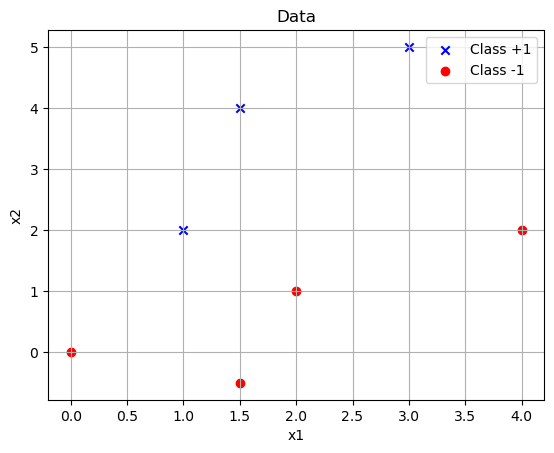

In [1]:
# Import the matplotlib library for plotting
import matplotlib.pyplot as plt

# Toy perceptron example
# Each input is [x1, x2], label is +1 if x2 > x1, else -1

X_toy = [
    [1.5, 4],
    [1, 2],   
    [2, 1],   
    [3, 5],
    [4, 2],   
    [0, 0],
    [1.5, -0.5] 
]
y_toy = [1, 1, -1, 1, -1, -1, -1]

# Separate points by class for coloring
def plot_points(X_points, y_labels):
    X_pos = [x for x, y in zip(X_points, y_labels) if y == 1]
    X_neg = [x for x, y in zip(X_points, y_labels) if y == -1]

    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos], color='blue', marker='x', label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg], color='red', marker='o',  label='Class -1')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Data')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_points(X_toy, y_toy)

### What is a Hyperplane?

A **hyperplane** is a generalization of the concept of a plane. In two dimensions, this is a line; in three dimensions, it is a flat surface or a plane. When we move to four or more dimensions, we call this flat, infinitely extending surface a hyperplane.

- In **2D**, a hyperplane is a line.
- In **3D**, a hyperplane is a plane.
- In **nD** (where n > 3), a hyperplane is an (n-1)-dimensional subspace.

*More details on plane, hyperplanes, and subspaces in your linear algebra classes.*

In [2]:
# Complete the perceptron prediction function below
def perceptron_predict(x, w, b):
    '''
    x: 2D input list [x1, x2]
    w: 2D weight list [w1, w2]
    b: bias term
    '''
    # You can assume x is a list of two elements [x1, x2]
    # Score = w_1*x_1 + w_2*x_2 + b
    score = w[0]*x[0] + w[1]*x[1] + b
    # Return +1 if score >= 0 else -1
    if (score >= 0) :
        return 1
    else:
        return -1

In [3]:
# Test cases for perceptron_predict with 2D input x

# Case 1: score > 0
assert perceptron_predict([2, 3], [1, 1], -4) == 1  # 2*1 + 3*1 - 4 = 1 >= 0

# Case 2: score == 0
assert perceptron_predict([1, 1], [2, -1], -1) == 1  # 1*2 + 1*(-1) - 1 = 0

# Case 3: score < 0
assert perceptron_predict([0, 1], [1, 2], -3) == -1  # 0*1 + 1*2 - 3 = -1 < 0

# Case 4: negative weights
assert perceptron_predict([2, 2], [-1, -1], 3) == -1  # 2*-1 + 2*-1 + 3 = -2 -2 + 3 = -1 < 0 -> -1

# Case 5: bias only
assert perceptron_predict([0, 0], [0, 0], 2) == 1    # 0 + 0 + 2 = 2 >= 0

print("All perceptron_predict test cases passed.")

All perceptron_predict test cases passed.


In [4]:
# Test cases for perceptron_predict with X_toy data set

# Set the parameters to be all 1
w = [1, 1]
b = 1

for x, y_label in zip(X_toy, y_toy):
    y_pred = perceptron_predict(x, w, b)
    print(f"Input: {x}, Actual label: {y_label}, Predicted: {y_pred}")

Input: [1.5, 4], Actual label: 1, Predicted: 1
Input: [1, 2], Actual label: 1, Predicted: 1
Input: [2, 1], Actual label: -1, Predicted: 1
Input: [3, 5], Actual label: 1, Predicted: 1
Input: [4, 2], Actual label: -1, Predicted: 1
Input: [0, 0], Actual label: -1, Predicted: 1
Input: [1.5, -0.5], Actual label: -1, Predicted: 1


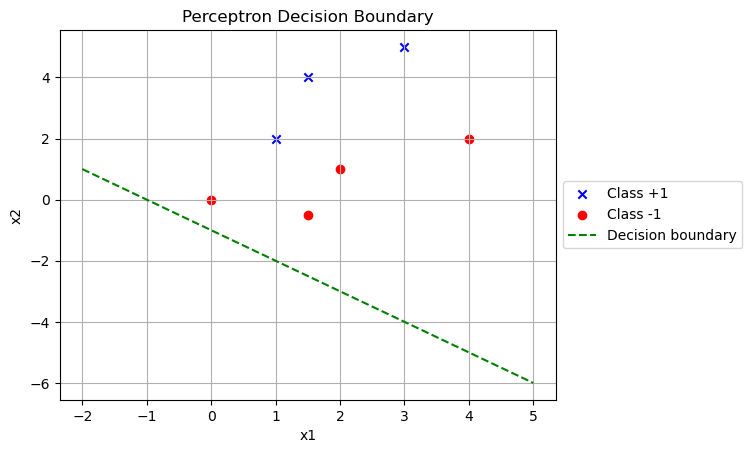

In [5]:
# It'll be helpful to visualize the decision boundary for given parameters values

import numpy as np

# Plot the toy data and the decision boundary using current w and b
def plot_perceptron_decision_boundary(X_points, y_labels, w, b, current_points=None):
    X_pos = [x for x, y in zip(X_points, y_labels) if y == 1]
    X_neg = [x for x, y in zip(X_points, y_labels) if y == -1]
    # Highlight current points if provided
    if current_points is not None:
        for pt in current_points:
            plt.scatter(pt[0], pt[1], color='gold', edgecolor='black', s=120, marker='*', label='Current point')
    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos], color='blue', marker='x', label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg], color='red', marker='o', label='Class -1')

    x1_vals = np.linspace(-2, 5, 100)
    # Robust handling for zero weights
    if w[0] == 0 and w[1] == 0:
        plt.text(0.5, 0.5, "No decision boundary\n(w1=0, w2=0)",
                 fontsize=14, color='red', ha='center', va='center', transform=plt.gca().transAxes)
    elif w[1] != 0:
        x2_vals = [-(w[0]/w[1])*x1 - b/w[1] for x1 in x1_vals]
        plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision boundary')
    elif w[0] != 0:
        plt.axvline(x=-b/w[0], color='green', linestyle='--', label='Decision boundary')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Perceptron Decision Boundary')
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
    plt.grid(True)
    plt.show()

# Here's an example of how the plot looks with the toy data set
# and with w = [1,1], b = 1
plot_perceptron_decision_boundary(X_toy, y_toy, w, b)

In [6]:
# To manually improve the decision boundary, we can use interactive sliders 
# in the plot to adjust the model parameters

from ipywidgets import interact, FloatSlider

def interactive_perceptron_plot(w1=1.0, w2=1.0, b=1.0):
    w = [w1, w2]
    # Plot data points
    X_pos = [x for x, y in zip(X_toy, y_toy) if y == 1]
    X_neg = [x for x, y in zip(X_toy, y_toy) if y == -1]

    plt.figure(figsize=(6, 5))
    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos], color='blue', marker='x', label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg], color='red', marker='o', label='Class -1')

    # Show predictions for each point
    for x, y_true in zip(X_toy, y_toy):
        score = w[0] * x[0] + w[1] * x[1] + b
        y_pred = 1 if score >= 0 else -1
        plt.text(x[0]+0.1, x[1], f'Pred: {y_pred}', fontsize=9, color='black')

    # Plot decision boundary: w1*x1 + w2*x2 + b = 0
    x1_vals = np.linspace(-2, 5, 100)
    if w1 == 0 and w2 == 0:
        plt.text(0.5, 0.5, "No decision boundary\n(w1=0, w2=0)", 
                 fontsize=14, color='red', ha='center', va='center', transform=plt.gca().transAxes)
    elif w2 != 0:
        x2_vals = [-(w1/w2)*x1 - b/w2 for x1 in x1_vals]
        plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision boundary')
    elif w1 != 0:
        plt.axvline(x=-b/w1, color='green', linestyle='--', label='Decision boundary')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Perceptron: w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}')
    plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
    plt.grid(True)
    plt.show()

interact(
    interactive_perceptron_plot,
    w1=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w1'),
    w2=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w2'),
    b=FloatSlider(value=1, min=-10, max=10, step=0.1, description='b')
)

interactive(children=(FloatSlider(value=1.0, description='w1', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

<function __main__.interactive_perceptron_plot(w1=1.0, w2=1.0, b=1.0)>

### How does the perceptron learn?

The perceptron learns by updating its weights and bias whenever it makes a mistake on a training example.

- For each training example, it computes the score: 
    $$
      score = \sum_{i=1}^n w_i x_i + b
    $$
- It predicts the class based on the sign of the score.
- If the prediction is wrong, it *updates* the weights and bias to reduce future mistakes:

  **Update rule:**

  - For each feature $i$:
    - $w_i = w_i + y \cdot x_i$
  - Bias:
    - $b = b + y$

  Here, $y$ is the true label (+1 or -1), and $x_i$ is the value of feature $i$.

This update nudges the model to be more likely to predict the correct class next time for similar examples.

An **epoch** is one iteration of this process through the training data.

In [7]:
# Perceptron learning: one iteration over the toy data
# For each data point, the model checks whether its prediction is correct, and # if not updates the weights and bias.
def perceptron_epoch(X_list, y_list, w_initial, b_initial):
    '''
    X_list: 2D input list
    y_list: actual values list
    w_initial: 2D initial weight list [w1, w2]
    b_initial: initial bias term
    '''
    w_learn = w_initial
    b_learn = b_initial

    for x, y_true in zip(X_list, y_list):
        print("---Next data point:\n")
    
        score = w_learn[0] * x[0] + w_learn[1] * x[1] + b_learn
        y_pred = 1 if score >= 0 else -1
        print(f"x={x}, y_true = {y_true}, old w = {w_learn}, old b = {b_learn}, old score = {score}, y_pred = {y_pred}")
        if y_pred != y_true:
            # Update weights
            for i in range(len(w_learn)):
                w_learn[i] += y_true * x[i]
            # Update bias
            b_learn += y_true

        print(f"x={x}, y_true = {y_true}, new w = {w_learn}, new b = {b_learn}, new score = {score}")
        plot_perceptron_decision_boundary(X_toy, y_toy, w_learn, b_learn, current_points=[x])
    
    return w_learn, b_learn


---Next data point:

x=[1.5, 4], y_true = 1, old w = [1, 1], old b = 1, old score = 6.5, y_pred = 1
x=[1.5, 4], y_true = 1, new w = [1, 1], new b = 1, new score = 6.5


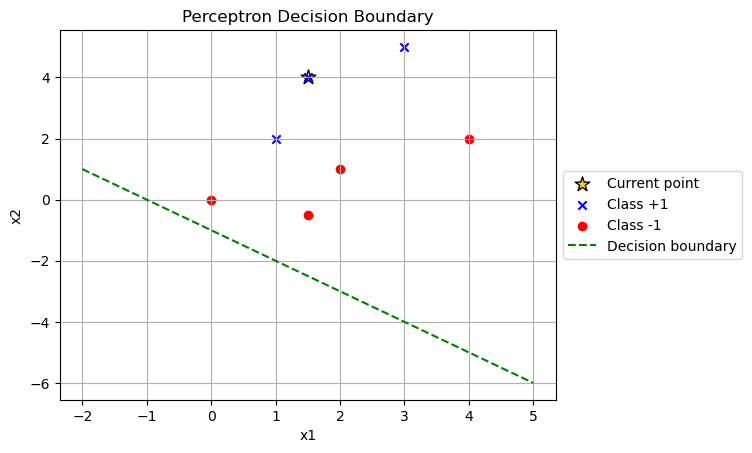

---Next data point:

x=[1, 2], y_true = 1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[1, 2], y_true = 1, new w = [1, 1], new b = 1, new score = 4


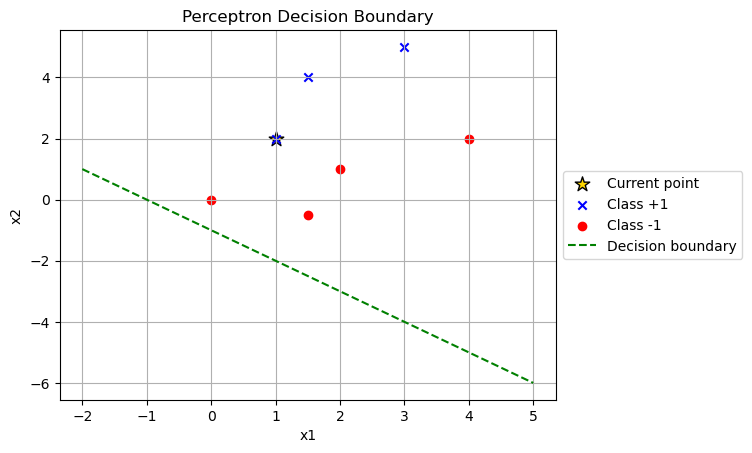

---Next data point:

x=[2, 1], y_true = -1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[2, 1], y_true = -1, new w = [-1, 0], new b = 0, new score = 4


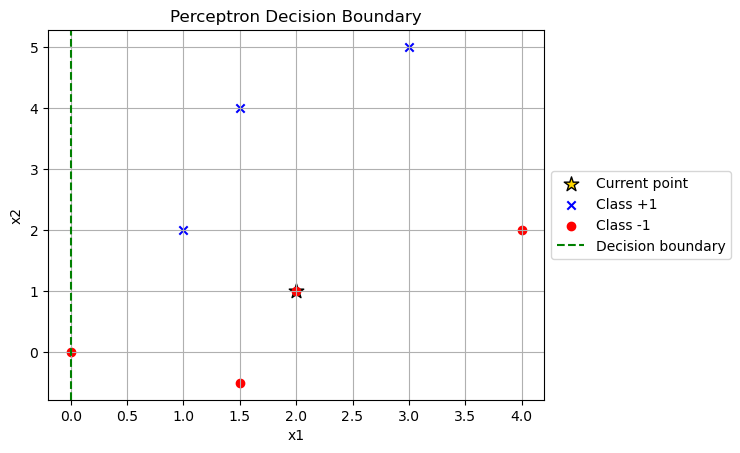

---Next data point:

x=[3, 5], y_true = 1, old w = [-1, 0], old b = 0, old score = -3, y_pred = -1
x=[3, 5], y_true = 1, new w = [2, 5], new b = 1, new score = -3


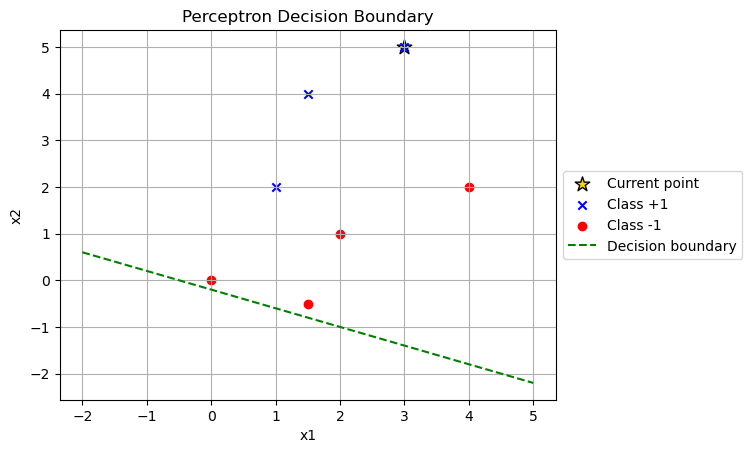

---Next data point:

x=[4, 2], y_true = -1, old w = [2, 5], old b = 1, old score = 19, y_pred = 1
x=[4, 2], y_true = -1, new w = [-2, 3], new b = 0, new score = 19


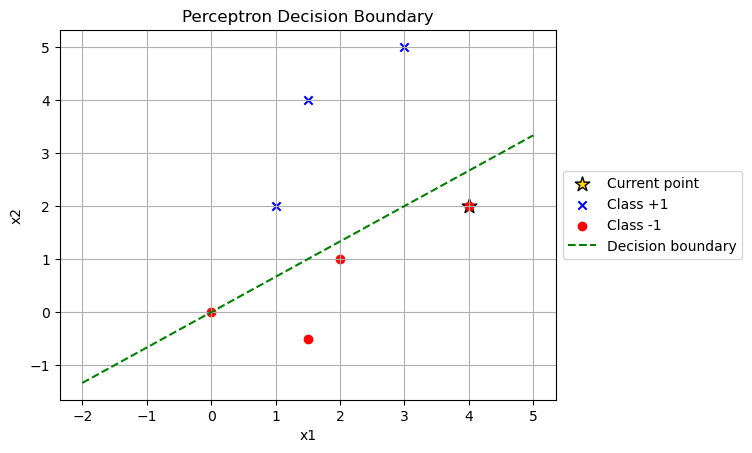

---Next data point:

x=[0, 0], y_true = -1, old w = [-2, 3], old b = 0, old score = 0, y_pred = 1
x=[0, 0], y_true = -1, new w = [-2, 3], new b = -1, new score = 0


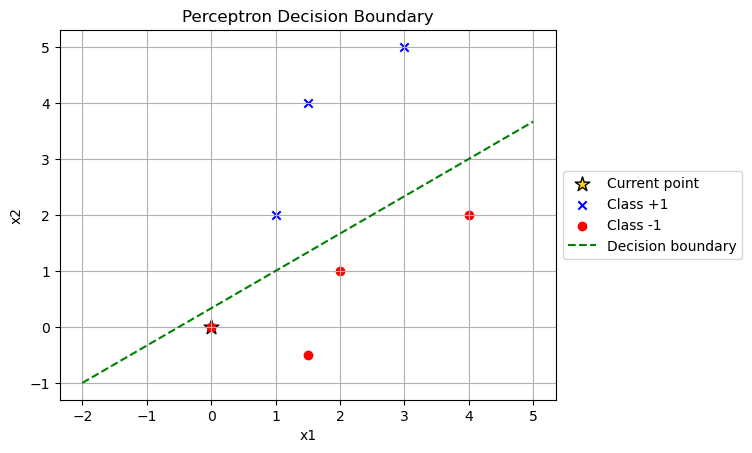

---Next data point:

x=[1.5, -0.5], y_true = -1, old w = [-2, 3], old b = -1, old score = -5.5, y_pred = -1
x=[1.5, -0.5], y_true = -1, new w = [-2, 3], new b = -1, new score = -5.5


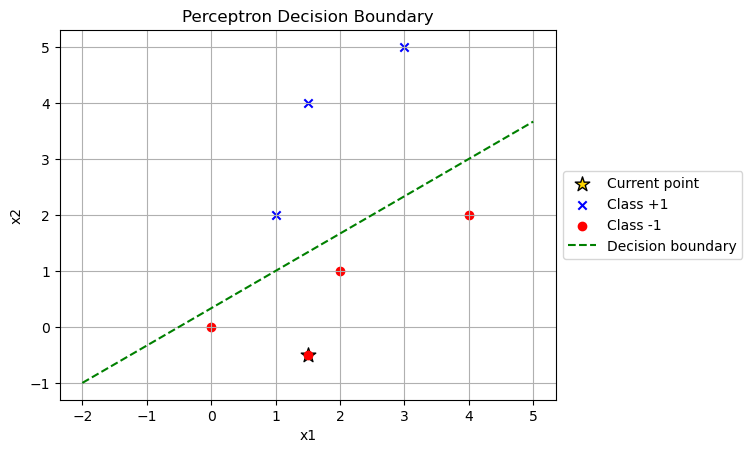

([-2, 3], -1)

In [8]:
# Let's run the perceptron for one epoch on the toy data set 
perceptron_epoch(X_toy, y_toy, [1, 1], 1)

Now, let's do the same thing, with the same data, just ordered differently. 

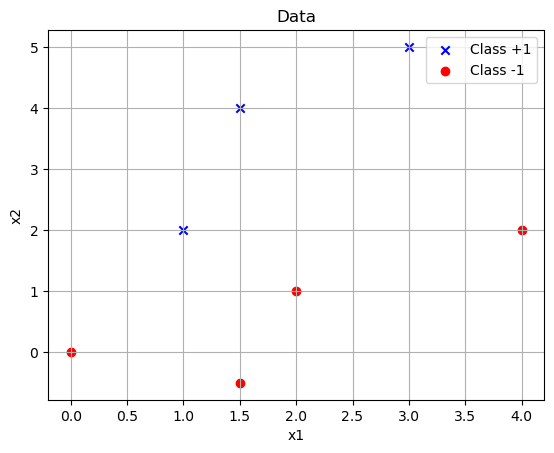

---Next data point:

x=[1.5, 4], y_true = 1, old w = [1, 1], old b = 1, old score = 6.5, y_pred = 1
x=[1.5, 4], y_true = 1, new w = [1, 1], new b = 1, new score = 6.5


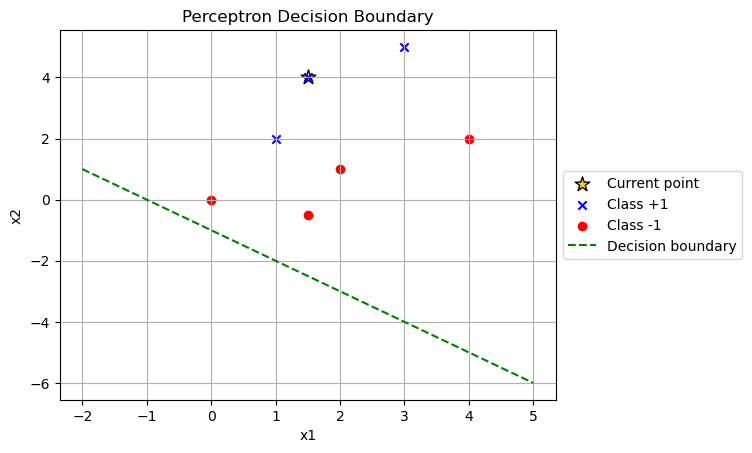

---Next data point:

x=[1, 2], y_true = 1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[1, 2], y_true = 1, new w = [1, 1], new b = 1, new score = 4


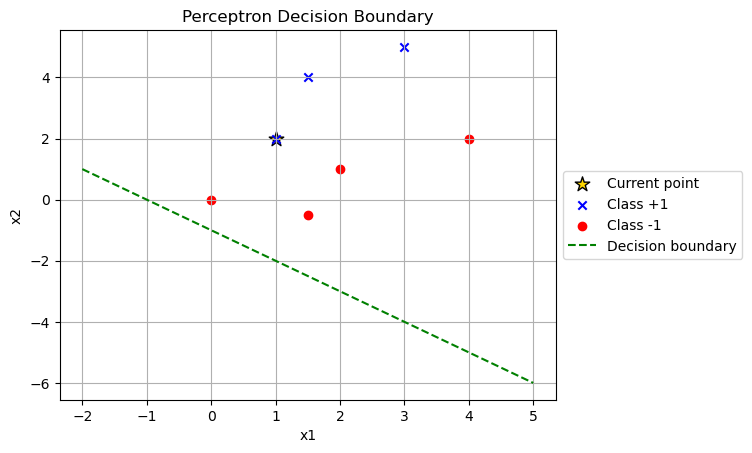

---Next data point:

x=[3, 5], y_true = 1, old w = [1, 1], old b = 1, old score = 9, y_pred = 1
x=[3, 5], y_true = 1, new w = [1, 1], new b = 1, new score = 9


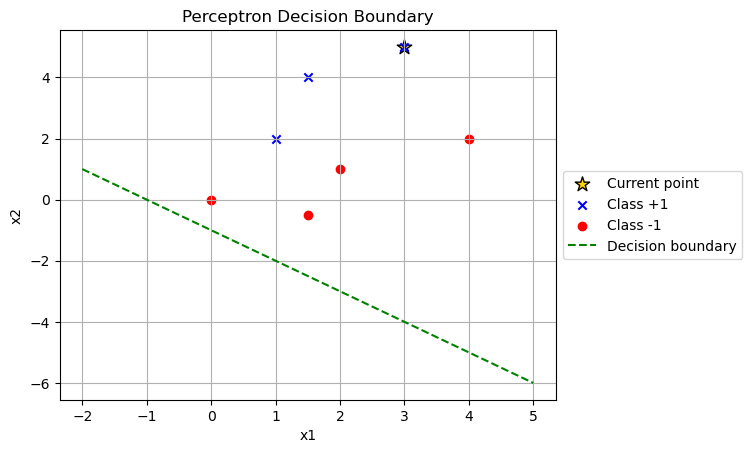

---Next data point:

x=[2, 1], y_true = -1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[2, 1], y_true = -1, new w = [-1, 0], new b = 0, new score = 4


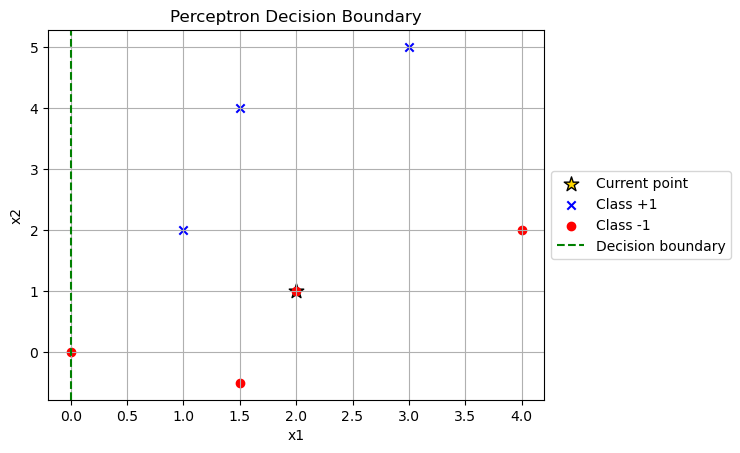

---Next data point:

x=[4, 2], y_true = -1, old w = [-1, 0], old b = 0, old score = -4, y_pred = -1
x=[4, 2], y_true = -1, new w = [-1, 0], new b = 0, new score = -4


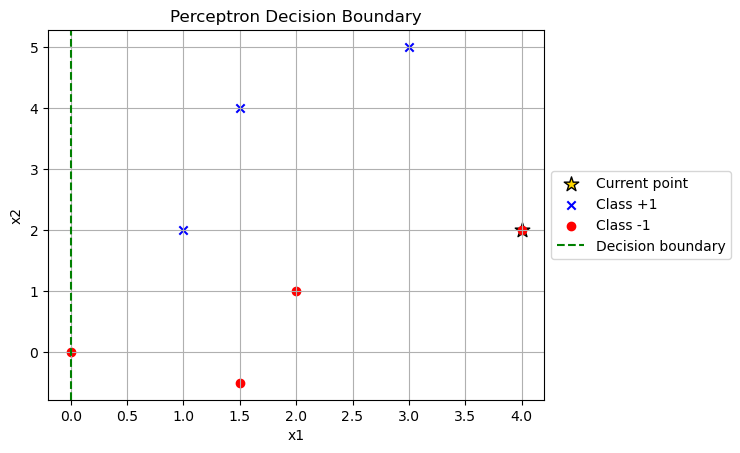

---Next data point:

x=[0, 0], y_true = -1, old w = [-1, 0], old b = 0, old score = 0, y_pred = 1
x=[0, 0], y_true = -1, new w = [-1, 0], new b = -1, new score = 0


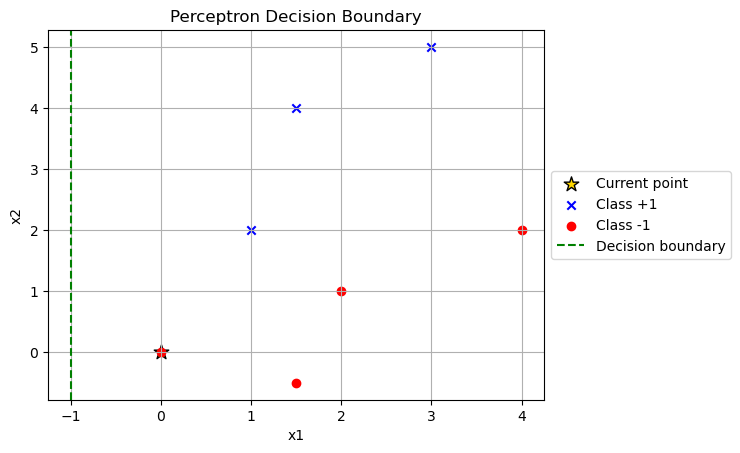

---Next data point:

x=[1.5, -0.5], y_true = -1, old w = [-1, 0], old b = -1, old score = -2.5, y_pred = -1
x=[1.5, -0.5], y_true = -1, new w = [-1, 0], new b = -1, new score = -2.5


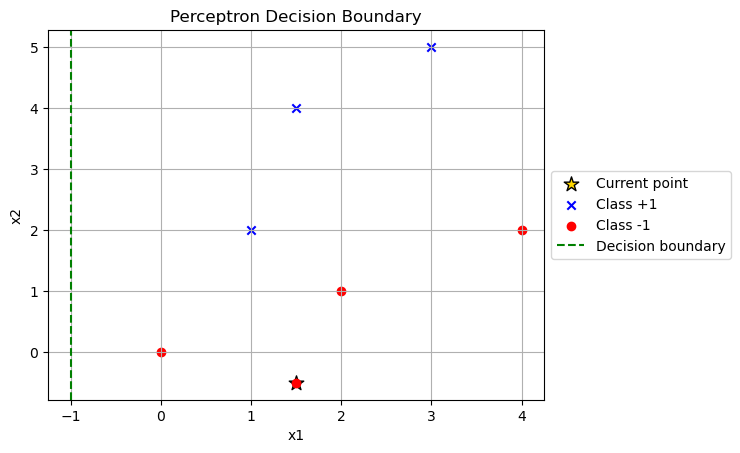

([-1, 0], -1)

In [9]:
X_toy_ordered = [
[1.5, 4],
[1, 2],
[3, 5],
[2, 1],
[4, 2],
[0, 0],
[1.5, -0.5]
]

y_toy_ordered = [1, 1, 1, -1, -1, -1, -1]

plot_points(X_toy_ordered, y_toy_ordered)

# Perceptron learning: one epoch over the data
perceptron_epoch(X_toy_ordered, y_toy_ordered, [1, 1], 1)

### What happened?
Discuss:
- What happened? Why did the model not learn the correct decision boundary?

The data in the ordered toy data set had all the data points with one label first, and then all the data points with the other label next. So the algorithm "forgets" about the structure that leads to the first label.

- What can we do to make it learn the decision boundary?

Shuffle the data set before we start.

In optimization, we can get stuck in regions of the search space. This is the difference between **local optima** and **global optima**

---Next data point:

x=[1, 2], y_true = 1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[1, 2], y_true = 1, new w = [1, 1], new b = 1, new score = 4


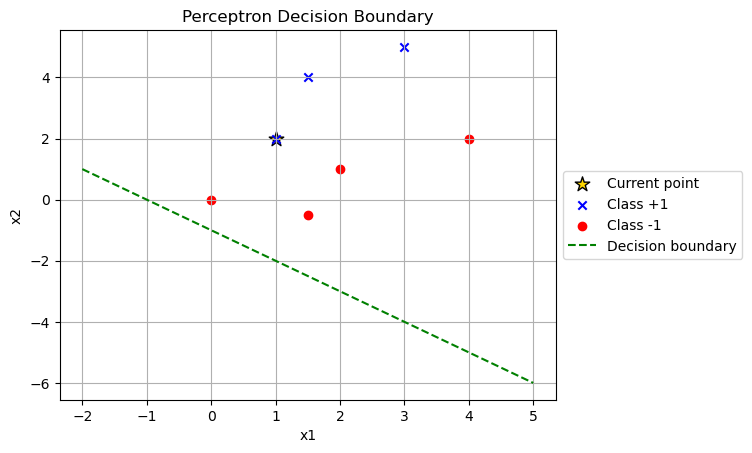

---Next data point:

x=[2, 1], y_true = -1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[2, 1], y_true = -1, new w = [-1, 0], new b = 0, new score = 4


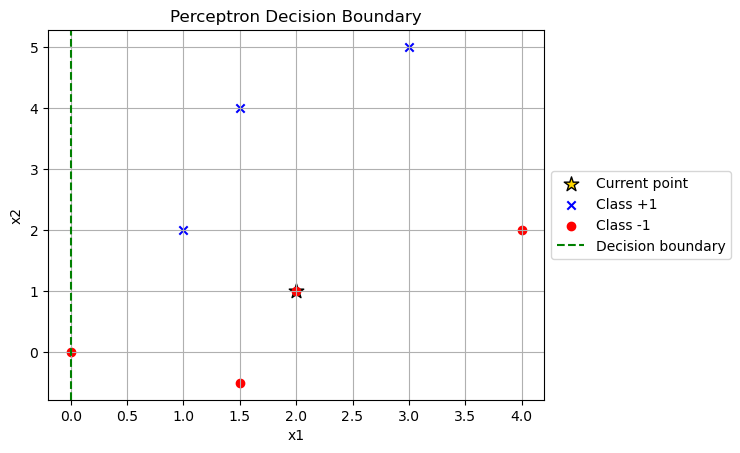

---Next data point:

x=[4, 2], y_true = -1, old w = [-1, 0], old b = 0, old score = -4, y_pred = -1
x=[4, 2], y_true = -1, new w = [-1, 0], new b = 0, new score = -4


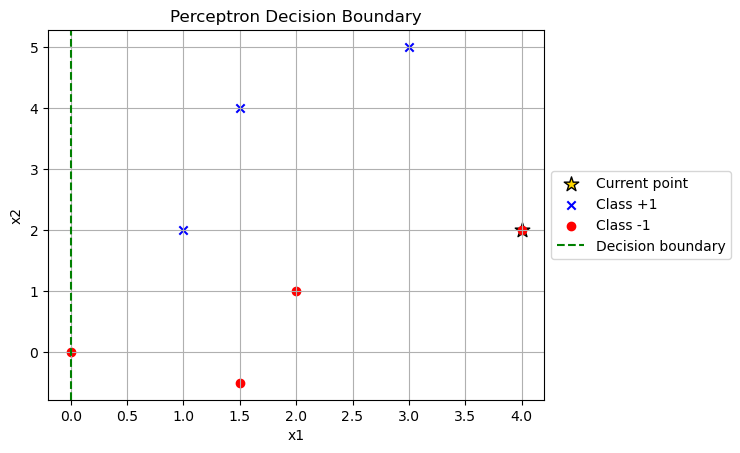

---Next data point:

x=[3, 5], y_true = 1, old w = [-1, 0], old b = 0, old score = -3, y_pred = -1
x=[3, 5], y_true = 1, new w = [2, 5], new b = 1, new score = -3


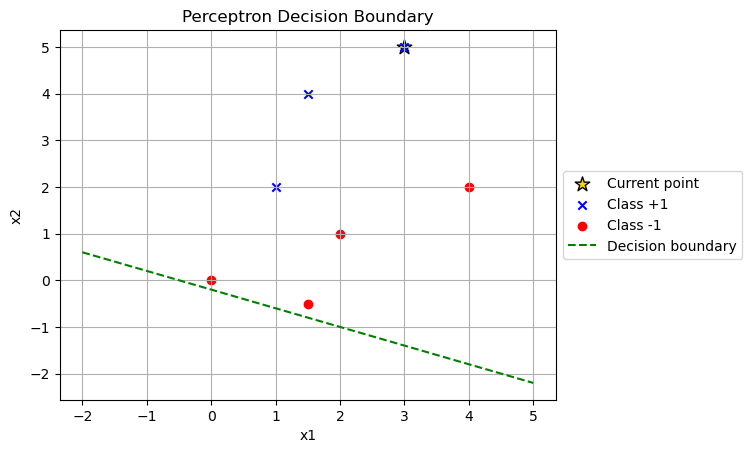

---Next data point:

x=[1.5, -0.5], y_true = -1, old w = [2, 5], old b = 1, old score = 1.5, y_pred = 1
x=[1.5, -0.5], y_true = -1, new w = [0.5, 5.5], new b = 0, new score = 1.5


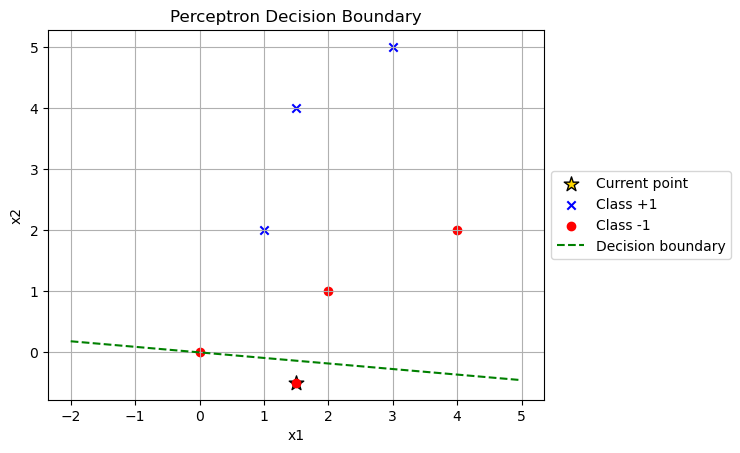

---Next data point:

x=[1.5, 4], y_true = 1, old w = [0.5, 5.5], old b = 0, old score = 22.75, y_pred = 1
x=[1.5, 4], y_true = 1, new w = [0.5, 5.5], new b = 0, new score = 22.75


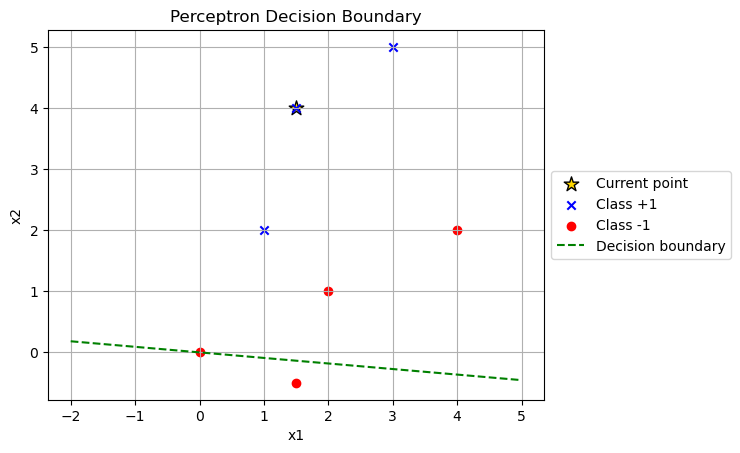

---Next data point:

x=[0, 0], y_true = -1, old w = [0.5, 5.5], old b = 0, old score = 0.0, y_pred = 1
x=[0, 0], y_true = -1, new w = [0.5, 5.5], new b = -1, new score = 0.0


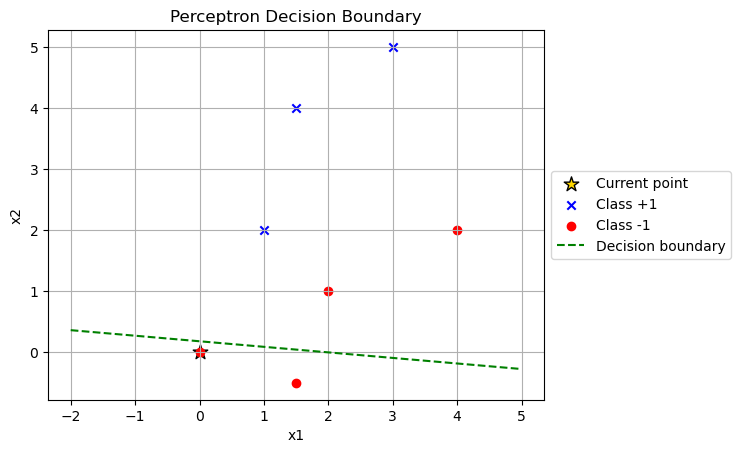

([0.5, 5.5], -1)

In [10]:
# Let's shuffle the data and do one epoch of perceptron learning

import random

random.seed(42) # for reproducibility

# This is another way to shuffle data so that X and y stay aligned
# You make a combination of X and y, shuffle that, then unzip back to X and y

# For zip, refer: https://docs.python.org/3/library/functions.html#zip 
combined = list(zip(X_toy_ordered, y_toy_ordered)) 

# Shuffle the combined data
random.shuffle(combined) # shuffle the combined data

# Unzip back to X and y with *combined
X_shuffled, y_shuffled = zip(*combined)

perceptron_epoch(X_shuffled, y_shuffled, [1, 1], 1)

Epoch: 1
---Next data point:

x=[1, 2], y_true = 1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[1, 2], y_true = 1, new w = [1, 1], new b = 1, new score = 4


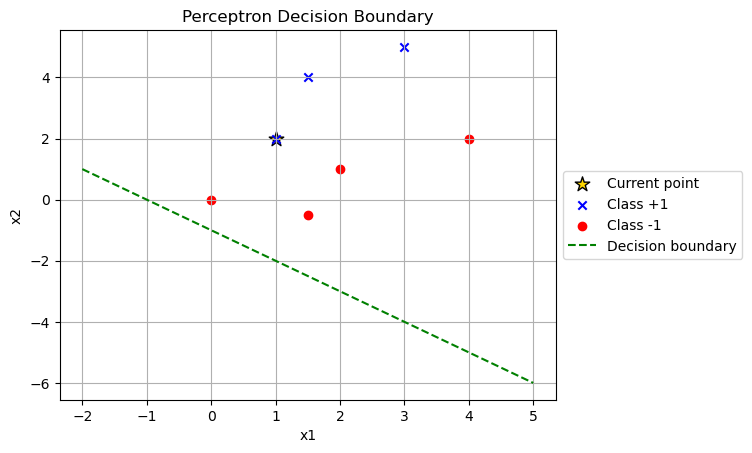

---Next data point:

x=[2, 1], y_true = -1, old w = [1, 1], old b = 1, old score = 4, y_pred = 1
x=[2, 1], y_true = -1, new w = [-1, 0], new b = 0, new score = 4


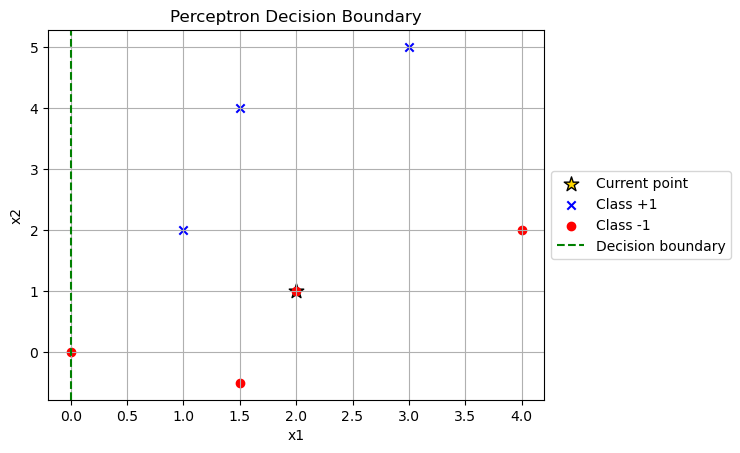

---Next data point:

x=[4, 2], y_true = -1, old w = [-1, 0], old b = 0, old score = -4, y_pred = -1
x=[4, 2], y_true = -1, new w = [-1, 0], new b = 0, new score = -4


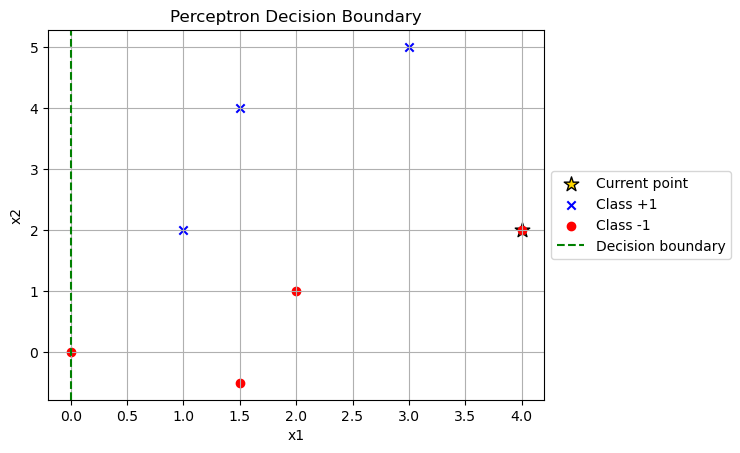

---Next data point:

x=[3, 5], y_true = 1, old w = [-1, 0], old b = 0, old score = -3, y_pred = -1
x=[3, 5], y_true = 1, new w = [2, 5], new b = 1, new score = -3


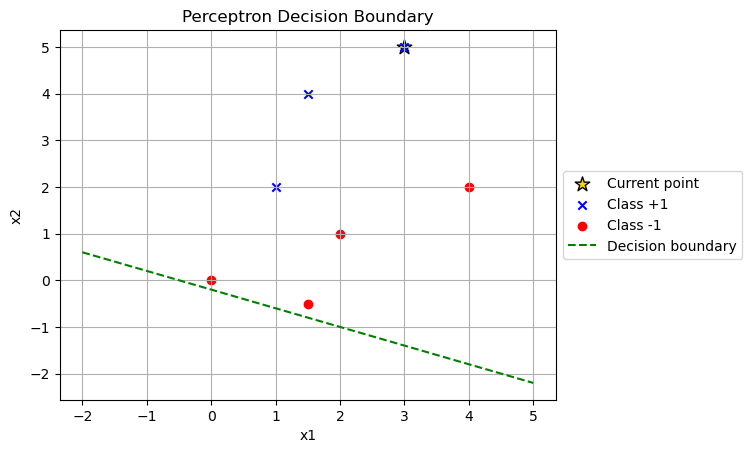

---Next data point:

x=[1.5, -0.5], y_true = -1, old w = [2, 5], old b = 1, old score = 1.5, y_pred = 1
x=[1.5, -0.5], y_true = -1, new w = [0.5, 5.5], new b = 0, new score = 1.5


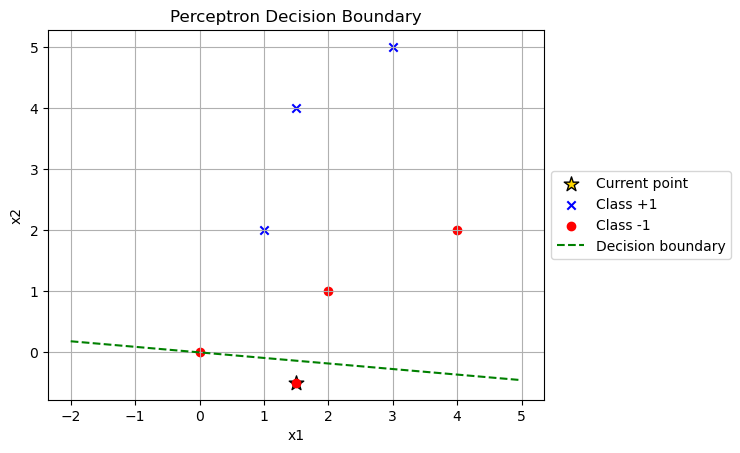

---Next data point:

x=[1.5, 4], y_true = 1, old w = [0.5, 5.5], old b = 0, old score = 22.75, y_pred = 1
x=[1.5, 4], y_true = 1, new w = [0.5, 5.5], new b = 0, new score = 22.75


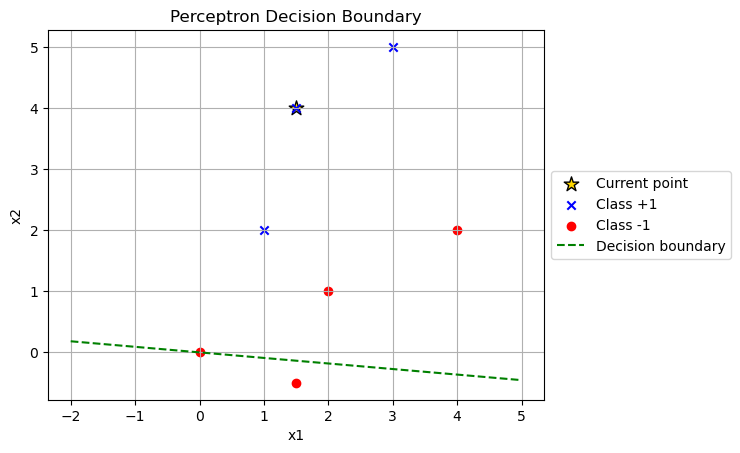

---Next data point:

x=[0, 0], y_true = -1, old w = [0.5, 5.5], old b = 0, old score = 0.0, y_pred = 1
x=[0, 0], y_true = -1, new w = [0.5, 5.5], new b = -1, new score = 0.0


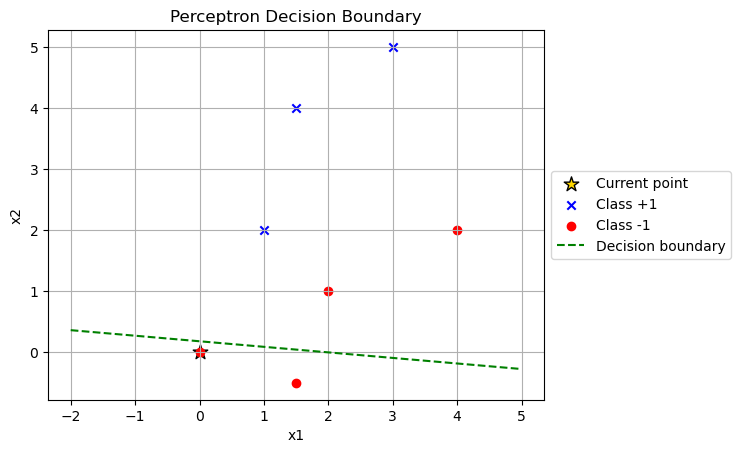

Epoch: 2
---Next data point:

x=[2, 1], y_true = -1, old w = [0.5, 5.5], old b = -1, old score = 5.5, y_pred = 1
x=[2, 1], y_true = -1, new w = [-1.5, 4.5], new b = -2, new score = 5.5


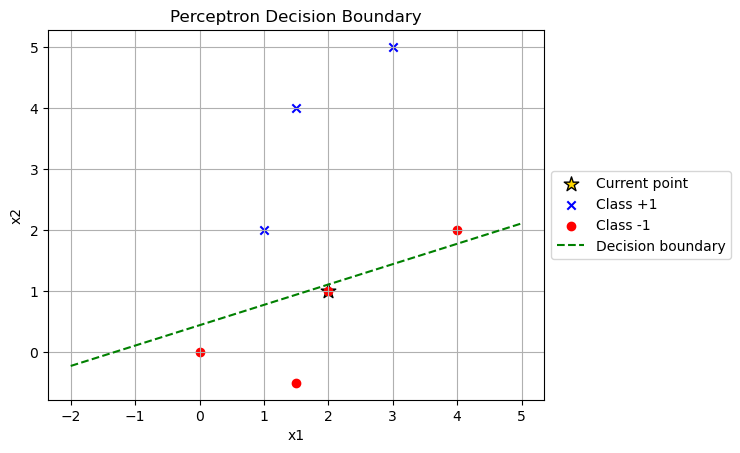

---Next data point:

x=[1.5, -0.5], y_true = -1, old w = [-1.5, 4.5], old b = -2, old score = -6.5, y_pred = -1
x=[1.5, -0.5], y_true = -1, new w = [-1.5, 4.5], new b = -2, new score = -6.5


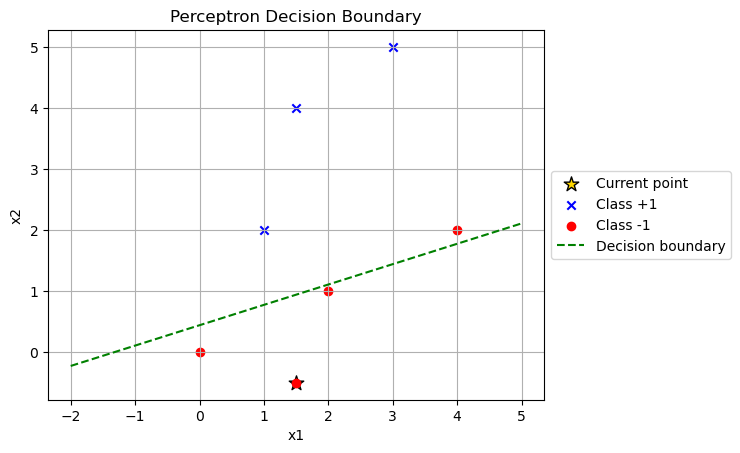

---Next data point:

x=[3, 5], y_true = 1, old w = [-1.5, 4.5], old b = -2, old score = 16.0, y_pred = 1
x=[3, 5], y_true = 1, new w = [-1.5, 4.5], new b = -2, new score = 16.0


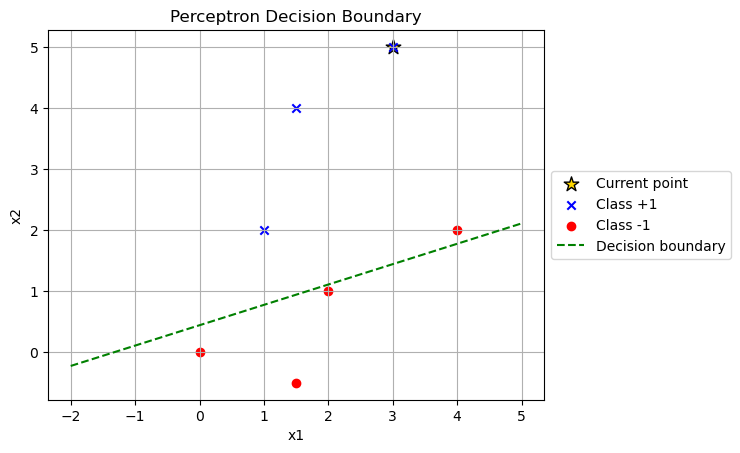

---Next data point:

x=[4, 2], y_true = -1, old w = [-1.5, 4.5], old b = -2, old score = 1.0, y_pred = 1
x=[4, 2], y_true = -1, new w = [-5.5, 2.5], new b = -3, new score = 1.0


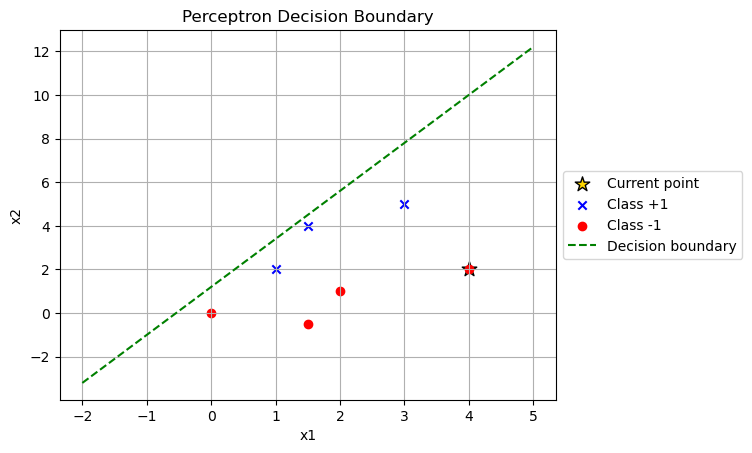

---Next data point:

x=[1.5, 4], y_true = 1, old w = [-5.5, 2.5], old b = -3, old score = -1.25, y_pred = -1
x=[1.5, 4], y_true = 1, new w = [-4.0, 6.5], new b = -2, new score = -1.25


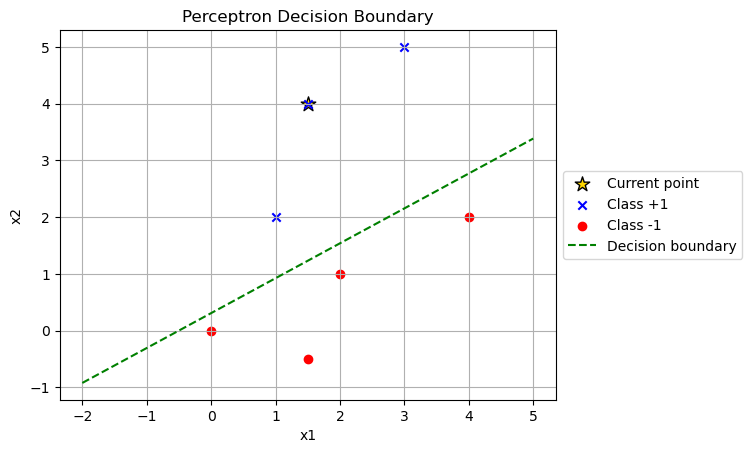

---Next data point:

x=[0, 0], y_true = -1, old w = [-4.0, 6.5], old b = -2, old score = -2.0, y_pred = -1
x=[0, 0], y_true = -1, new w = [-4.0, 6.5], new b = -2, new score = -2.0


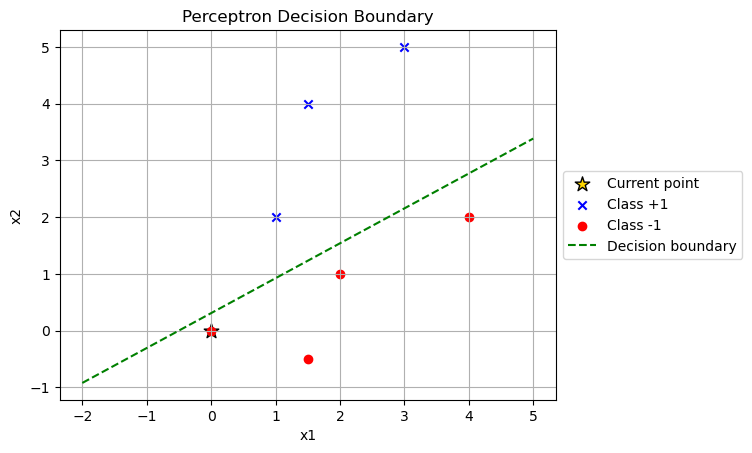

---Next data point:

x=[1, 2], y_true = 1, old w = [-4.0, 6.5], old b = -2, old score = 7.0, y_pred = 1
x=[1, 2], y_true = 1, new w = [-4.0, 6.5], new b = -2, new score = 7.0


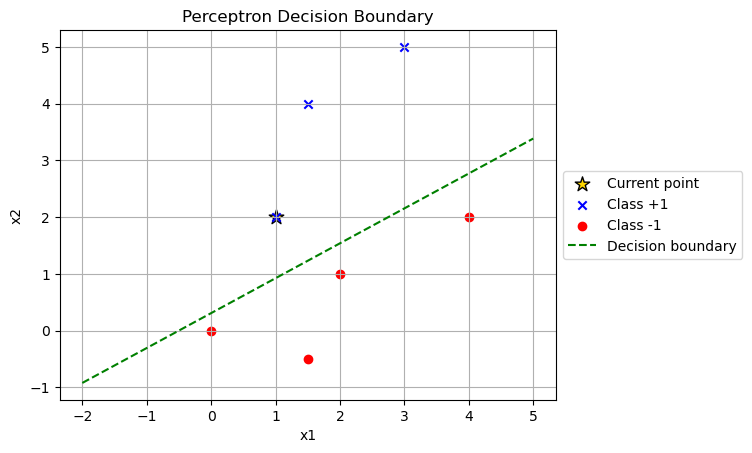

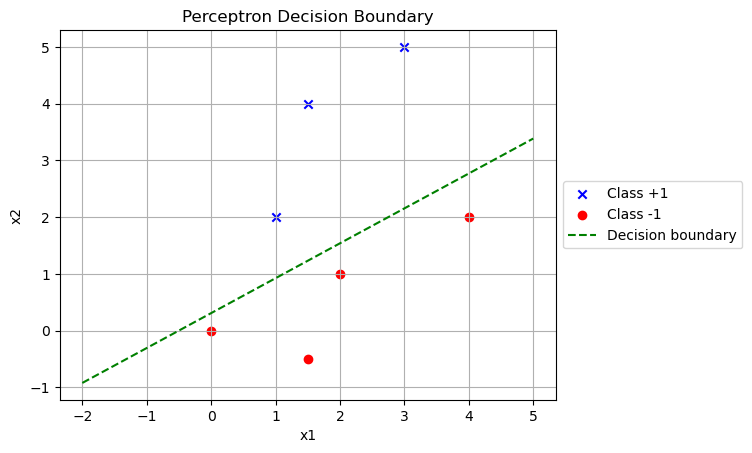

In [11]:
# We can also run multiple epochs and shuffle the data at each epoch
# Number of epochs
num_epochs = 2

w_learn = [1, 1]  # initial weights
b_learn = 1       # initial bias  
random.seed(42) # for reproducibility

for epoch in range(num_epochs):
    combined = list(zip(X_toy_ordered, y_toy_ordered))
    random.shuffle(combined)
    X_shuffled, y_shuffled = zip(*combined)
    print(f"Epoch: {epoch+1}")
    w_learn, b_learn = perceptron_epoch(X_shuffled, y_shuffled, w_learn, b_learn)
    
plot_perceptron_decision_boundary(X_toy_ordered, y_toy_ordered, w_learn, b_learn)

##### Shuffling and Multiple Epochs in Perceptron Training

In practice, training a perceptron involves more than just a single pass over the data:

- **Shuffling the Data:**  
    In each epoch (or iteration), we randomly shuffle the order of the training examples. This prevents the perceptron from getting stuck in patterns caused by the order of the data and helps it learn a better decision boundary.

- **Multiple Epochs:**  
    Instead of updating the weights just once for each example, we repeat the process for several epochs. In each epoch, the perceptron sees all the training examples (in a new random order), updating its weights whenever it makes a mistake.  
    Running multiple epochs gives the perceptron more chances to correct its mistakes and converge to a solution that separates the classes (if possible).

This approach improves learning and helps the perceptron find a good decision boundary.

## Evaluation for classification tasks

Once a classification model is trained, how do we **evaluate** it?

In regression, we used an error function to describe the goodness of fit of the model to its training data set.

In **classification**, we often use **accuracy** to evaluate a model. Accuracy describes how often a model predicts the correct class label.

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

We will work with a **binary classification** setting where labels are:
- `1` = positive class
- `0` = negative class

A model outputs a **predicted label** for each example.

In [12]:
# Toy example: True labels and model predictions
y_true = [1, 0, 1, 0, 0, 1, 1, 0] # true labels
y_pred = [1, 0, 0, 0, 0, 1, 0, 0] # model predictions

Q. Compute the **accuracy** for the toy example above.

Number of correct predictions: 6
Total number of predictions: 8
Accuracy: 0.75

In [13]:
# Accuracy is the ratio of correct predictions over total predictions
def accuracy(y_true, y_pred):
    '''
    y_true: list of true labels for data
    y_pred: list of predicated labels for data
    Return accuracy = (# correct) / (total).
    '''
    total_correct = 0
    for y_tv, y_p in zip(y_true, y_pred):
        if (y_tv == y_p): 
            total_correct += 1
    return (total_correct*1.0) / len(y_pred)


In [14]:
# Test cases for the accuracy function
assert accuracy([1, 0, 1], [1, 0, 1]) == 1.0  # all correct
assert accuracy([1, 0, 1], [0, 0, 1]) == 2/3  # one incorrect
assert accuracy([0, 0, 0], [1, 1, 1]) == 0.0  # all incorrect
assert accuracy([1, 1, 0, 0], [1, 0, 0, 1]) == 0.5  # two correct

print("All accuracy tests passed.")

print(f"Accuracy for toy example is: {accuracy(y_true,y_pred)}")


All accuracy tests passed.
Accuracy for toy example is: 0.75


Let's explore some situations where this accuracy metric may be misleading.  In particular, if one class is `rare but important` we can get imbalanced datasets. For example: 
- *fraud detection*, 
- *disease screening*, 
- *spam filtering*, or 
- *anomaly detection*.

Because most examples belong to the majority class, a model can predict only that class and still achieve very high accuracy. The metric hides the fact that the model completely fails to detect the rare events we actually care about.

In [15]:
# Here's a concrete example of what happens when we have an imbalanced dataset

imbalanced_y_true = [0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1] # true labels                   
imbalanced_y_pred = [0]*21 # model predictions are all 0 (a very simple model)

print("Accuracy on imbalanced dataset:", accuracy(imbalanced_y_true, imbalanced_y_pred))

Accuracy on imbalanced dataset: 0.9047619047619048


### Confusion Matrix

Accuracy tells us overall correctness. A **confusion matrix** tells us *what kinds* of mistakes the model makes.

For binary classification:

- **TP**: true positive (true 1, predicted 1)  
- **FP**: false positive (true 0, predicted 1)  
- **FN**: false negative (true 1, predicted 0)  
- **TN**: true negative (true 0, predicted 0)


$$
\begin{array}{c|cc}
 & \textbf{Predicted 1} & \textbf{Predicted 0} \\
\hline
\textbf{Actual 1} & TP & FN \\
\textbf{Actual 0} & FP & TN \\
\end{array}
$$

In [16]:
# Complete the code in this function definition
# Python note: use and instead of & or the Java &

def confusion_counts(y_true, y_pred):
    TP = FP = FN = TN = 0
    for yt, yp in zip(y_true, y_pred):
        if (yt ==1) and (yp ==1):
            TP +=1
        elif (yt == 1) and (yp ==0):
            FN +=1
        elif (yt ==0) and (yp ==1):
            FP +=1 
        else: # yt == 0 and yp == 0
            TN +=1
        #print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN}

In [17]:
# Test cases for the confusion_counts function

# Case 1: All correct predictions
assert confusion_counts([1, 0, 1, 0], [1, 0, 1, 0]) == {'TP': 2, 'FP': 0, 'FN': 0, 'TN': 2}

# Case 2: All incorrect predictions
assert confusion_counts([1, 1, 0, 0], [0, 0, 1, 1]) == {'TP': 0, 'FP': 2, 'FN': 2, 'TN': 0}

# Case 3: Only true positives
assert confusion_counts([1, 1, 1], [1, 1, 1]) == {'TP': 3, 'FP': 0, 'FN': 0, 'TN': 0}

# Case 4: Only true negatives
assert confusion_counts([0, 0, 0], [0, 0, 0]) == {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 3}

# Case 5: Mixed predictions
assert confusion_counts([1, 0, 1, 0], [0, 1, 1, 0]) == {'TP': 1, 'FP': 1, 'FN': 1, 'TN': 1}

print("All confusion_counts tests passed.")
counts = confusion_counts(y_true, y_pred)
print("Counts from toy example:", counts)
imbalanced_counts = confusion_counts(imbalanced_y_true, imbalanced_y_pred)
print("Imbalanced counts:", imbalanced_counts)


All confusion_counts tests passed.
Counts from toy example: {'TP': 2, 'FP': 0, 'FN': 2, 'TN': 4}
Impalanced counts: {'TP': 0, 'FP': 0, 'FN': 2, 'TN': 19}


We can also compute the accuracy from these counts:

$$
\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$

Accuracy is the fraction of all predictions that are correct (correct positives + correct negatives over all cases).

#### Precision, Recall, F1

- **`Precision`**: Of all the examples the model *predicted* as positive, how many were actually positive?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- **`Recall`**: Of all the examples that are *actually* positive, how many did the model correctly identify? Recall is also known as *True Positive Rate (TPR)*.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


- **`F1`**: single score combining precision and recall (harmonic mean). It is high only when both precision and recall are high.
$$
F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$


![Precision vs Recall](images/Precisionrecall.png)

<sub>
Image source: "Precisionrecall.svg" via Wikimedia Commons. Licensed under CC BY-SA 3.0.  
https://commons.wikimedia.org/wiki/File:Precisionrecall.svg
</sub>

In [22]:
def precision_recall_f1(y_true, y_pred):
    '''
    Return precision, recall, and F1 score for binary classification.
    If undefined, return 0.0 for that metric.
    '''
    precision, recall, f1 = 0.0, 0.0, 0.0
    conf = confusion_counts(y_true, y_pred)
    # precision = TP / TP + FP
    if ((conf["TP"] + conf["FP"]) != 0):
        precision = conf["TP"] / (conf["TP"] + conf["FP"])
    # recall = TP / TP + FP
    if ((conf["TP"] + conf["FN"]) != 0):
        recall = conf["TP"] / (conf["TP"] + conf["FN"])
    # precision = TP / TP + FP
    if ( (precision + recall) !=0):
        f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1

In [23]:
# Test cases for precision_recall_f1

def _close(a, b, tol=1e-9):
    return abs(a - b) < tol

# Case 1: Existing toy example
p, r, f = precision_recall_f1(y_true, y_pred)
assert _close(p, 1.0)
assert _close(r, 0.5)
assert _close(f, 2/3)

# Case 2: Imbalanced example (predict all zeros)
p, r, f = precision_recall_f1(imbalanced_y_true, imbalanced_y_pred)
assert _close(p, 0.0)
assert _close(r, 0.0)
assert _close(f, 0.0)

# Case 3: All predictions are positive
p, r, f = precision_recall_f1([1, 0, 1, 0], [1, 1, 1, 1])
assert _close(p, 0.5)     # 2 TP / (2 TP + 2 FP)
assert _close(r, 1.0)     # 2 TP / (2 TP + 0 FN)
assert _close(f, 2/3)

# Case 4: No actual positives
p, r, f = precision_recall_f1([0, 0, 0], [0, 1, 0])
assert _close(p, 0.0)     # TP=0, FP=1
assert _close(r, 0.0)     # TP=0, FN=0 -> handled as 0.0
assert _close(f, 0.0)

# Case 5: No predicted positives
p, r, f = precision_recall_f1([1, 0, 1], [0, 0, 0])
assert _close(p, 0.0)     # TP=0, FP=0 -> handled as 0.0
assert _close(r, 0.0)     # TP=0, FN=2
assert _close(f, 0.0)

print("All precision_recall_f1 tests passed.")

prec, rec, f1 = precision_recall_f1(y_true, y_pred)
print("Precision, recall, f1 for toy example:",prec, rec, f1)

prec_imb, rec_imb, f1_imb = precision_recall_f1(imbalanced_y_true, imbalanced_y_pred)
print("Precision, recall, f1 for imbalanced example:", prec_imb, rec_imb, f1_imb)

All precision_recall_f1 tests passed.
Precision, recall, f1 for toy example: 1.0 0.5 0.6666666666666666
Precision, recall, f1 for imbalanced example: 0.0 0.0 0.0


## The XOR Problem: A Challenge for Perceptrons

The XOR (exclusive OR) function outputs true only when its two binary inputs differ. 

| X_1| X_2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

If we plot the four possible input combinations, we'll see that no single straight line can separate the points where XOR is true from those where it is false.

In the next cell - Try changing the values of the perceptron parameters (`w1`, `w2`, and `b`). Can you find any set of parameters that perfectly separates the blue and red points?

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# XOR dataset: inputs and labels
X_xor = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
y_xor = [-1, 1, 1, -1]  # XOR: output is 1 if exactly one input is 1, else -1

def plot_xor_perceptron(w1=0.0, w2=0.0, b=0.0):
    w = [w1, w2]
    # Separate points by class
    X_pos = [x for x, y in zip(X_xor, y_xor) if y == 1]
    X_neg = [x for x, y in zip(X_xor, y_xor) if y == -1]

    plt.figure(figsize=(4, 4))
    plt.scatter([x[0] for x in X_pos], [x[1] for x in X_pos], color='blue', marker='x', s=100, label='Class +1')
    plt.scatter([x[0] for x in X_neg], [x[1] for x in X_neg], color='red', marker='o', s=100, label='Class -1')

    # Plot decision boundary: w1*x1 + w2*x2 + b = 0
    x1_vals = np.linspace(-0.5, 1.5, 100)
    if w1 == 0 and w2 == 0:
        plt.text(0.5, 0.5, "No decision boundary\n(w1=0, w2=0)", 
                 fontsize=12, color='purple', ha='center', va='center', transform=plt.gca().transAxes)
    elif w2 != 0:
        x2_vals = [-(w1/w2)*x1 - b/w2 for x1 in x1_vals]
        plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision boundary')
    elif w1 != 0:
        plt.axvline(x=-b/w1, color='green', linestyle='--', label='Decision boundary')

    # Show predictions for each point
    for x, y_true in zip(X_xor, y_xor):
        score = w[0] * x[0] + w[1] * x[1] + b
        y_pred = 1 if score >= 0 else -1
        plt.text(x[0]+0.05, x[1]+0.05, f'Pred: {y_pred}', fontsize=10, color='black')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('XOR: Perceptron Decision Boundary')
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    # plt.legend()
    # Move the legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()


interact(
    plot_xor_perceptron,
    w1=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w1'),
    w2=FloatSlider(value=1, min=-5, max=5, step=0.1, description='w2'),
    b=FloatSlider(value=0, min=-5, max=5, step=0.1, description='b')
)

print("Try different values for w1, w2, and b. You will see that no straight line can separate the XOR classes perfectly.")

interactive(children=(FloatSlider(value=1.0, description='w1', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

Try different values for w1, w2, and b. You will see that no straight line can separate the XOR classes perfectly.


#### Limitation of the Perceptron

The inability to solve the XOR problem is a fundamental limitation of the single-layer perceptron. A single perceptron can only represent decision boundaries that are linear.

The XOR dataset is **not linearly separable**, meaning no single straight line can separate the classes. As a result, a single perceptron cannot solve the XOR problem.

#### Historical Context

The perceptron was introduced by Frank Rosenblatt in 1958 as one of the earliest models of an artificial neuron.  
Rosenblatt, F. (1958). The perceptron: A probabilistic model for information storage and organization in the brain. Psychological Review, 65(6), 386–408. https://doi.org/10.1037/h0042519

Later theoretical analysis by Marvin Minsky and Seymour Papert showed that single-layer perceptrons are incapable of computing certain functions, including XOR. Minsky, M., & Papert, S. (1969). Perceptrons. M.I.T. Press.

#### Overcoming the Limitation

A couple of ways to overcome this limitation:

- **Feature engineering:** By adding new features (such as a product term `x1 * x2`), you can make the XOR problem linearly separable. You’ll explore this approach in Programming Assignment 1 (PA1).

- **Multi-layer perceptrons:** By stacking perceptrons in layers (i.e., building multi-layer perceptrons), we can represent non-linear decision boundaries and solve problems like XOR. This will be covered in upcoming lectures.